Dataset generated successfully in 0.29 seconds!
Total Rows & Columns: (100000, 9)
Aggregation completed in 0.0714 seconds!

--- 100k Dataset Summary Dashboard ---
  ProductCategory  Total_Revenue  Average_Price  Total_Orders
0          Beauty   5.023710e+07     500.697880         16635
1           Books   5.031992e+07     503.117700         16703
2        Clothing   5.087565e+07     503.271340         16811
3     Electronics   4.992694e+07     503.835926         16507
4  Home & Kitchen   5.026251e+07     502.566191         16594
5          Sports   5.053596e+07     506.925821         16750


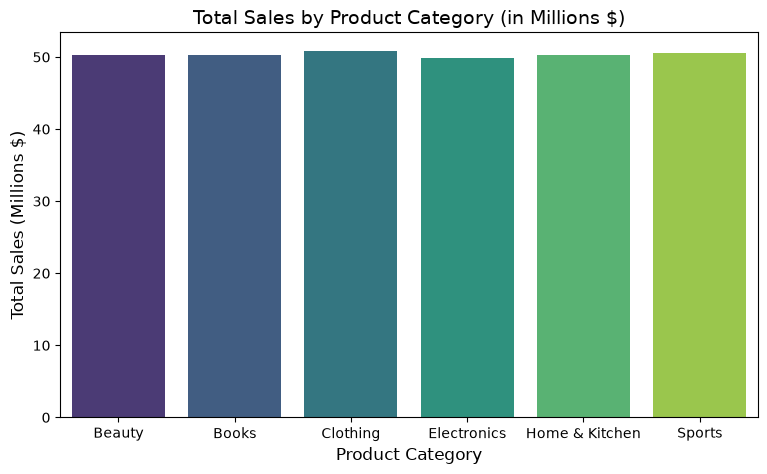

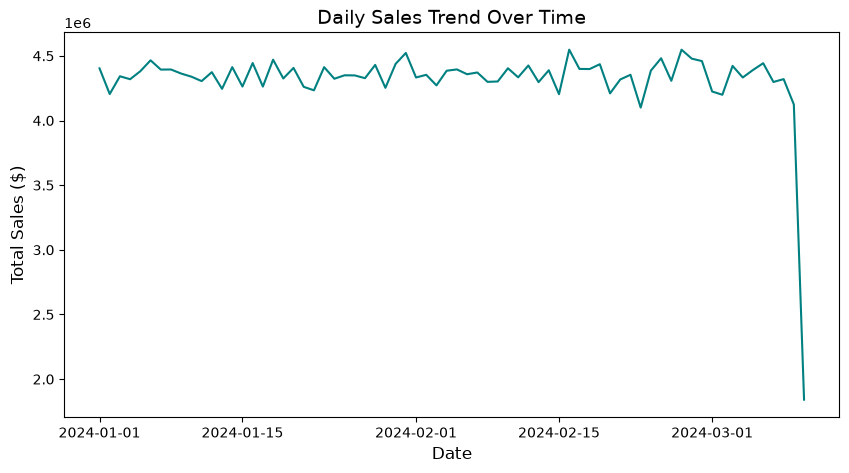

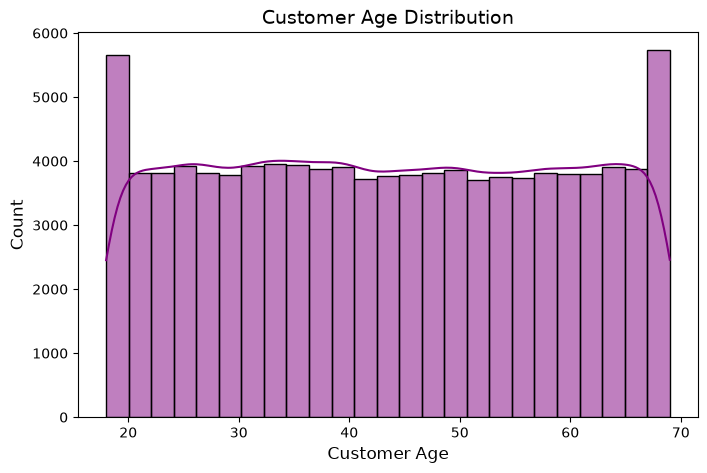

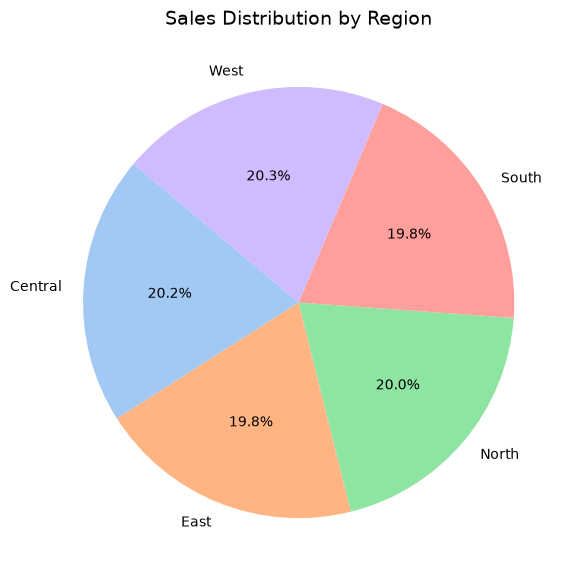

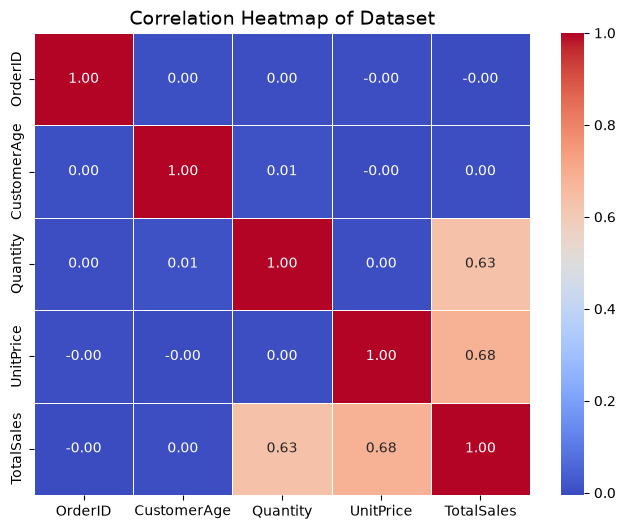

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()

n_rows = 100000
np.random.seed(67)

data = {
    'OrderID': range(10001, 10001 + n_rows),
    'CustomerAge': np.random.randint(18, 70, size=n_rows),
    'Gender': np.random.choice(['Male', 'Female', 'Other'], size=n_rows),
    'ProductCategory': np.random.choice(['Electronics', 'Clothing', 'Home & Kitchen', 'Sports', 'Beauty', 'Books'], size=n_rows),
    'Quantity': np.random.randint(1, 12, size=n_rows),
    'UnitPrice': np.random.uniform(5.0, 1000.0, size=n_rows),
    'OrderDate': pd.date_range(start='2024-01-01', periods=n_rows, freq='min'),
    'Region': np.random.choice(['North', 'South', 'East', 'West', 'Central'], size=n_rows)
}

df_large = pd.DataFrame(data)

df_large['TotalSales'] = df_large['Quantity'] * df_large['UnitPrice']
df_large.loc[np.random.choice(n_rows, 500), 'CustomerAge'] = np.nan

end_time = time.time()
print(f"Dataset generated successfully in {end_time - start_time:.2f} seconds!")
print("Total Rows & Columns:", df_large.shape)

start_time = time.time()

large_summary = df_large.groupby('ProductCategory').agg(
    Total_Revenue=('TotalSales', 'sum'),
    Average_Price=('UnitPrice', 'mean'),
    Total_Orders=('OrderID', 'count')
).reset_index()

end_time = time.time()
print(f"Aggregation completed in {end_time - start_time:.4f} seconds!")
print("\n--- 100k Dataset Summary Dashboard ---")
print(large_summary)

large_summary['Revenue_Millions'] = large_summary['Total_Revenue'] / 1000000

plt.figure(figsize=(9, 5))
sns.barplot(x='ProductCategory', y='Revenue_Millions', data=large_summary, palette='viridis', hue='ProductCategory', legend=False)
plt.title('Total Sales by Product Category (in Millions $)', fontsize=14)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales (Millions $)', fontsize=12)
plt.savefig('sales_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

df_large['DateOnly'] = df_large['OrderDate'].dt.date
daily_sales = df_large.groupby('DateOnly')['TotalSales'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='DateOnly', y='TotalSales', data=daily_sales, color='teal')
plt.title('Daily Sales Trend Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.savefig('sales_trend_time.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df_large['CustomerAge'].dropna(), bins=25, kde=True, color='purple')
plt.title('Customer Age Distribution', fontsize=14)
plt.xlabel('Customer Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.savefig('customer_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

region_summary = df_large.groupby('Region')['TotalSales'].sum().reset_index()

plt.figure(figsize=(7, 7))
plt.pie(region_summary['TotalSales'], labels=region_summary['Region'], autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Sales Distribution by Region', fontsize=14)
plt.savefig('region_sales_pie.png', dpi=300, bbox_inches='tight')
plt.show()

numeric_df = df_large.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Dataset', fontsize=14)
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()